In [1]:
from admmviz import ADMM
from matplotlib import pyplot as plt
import numpy as np

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Instantiate the admm object (the run history is saved in .h5 files in hierarchical format)
#### data directory structure : root/{alpha_value}/{dim}.h5

In [2]:
admm = ADMM(alpha=0.01, dim=128, base_dir="run_data_admm_running_avg_gurobi")

### trial(i) represents trial index for the randomized IP solver in the loop
### for randomized solver, there is a single trial : trial(0)

### The full JSON tree can be viewed using :

In [18]:
admm.trial(0).series.infeas

array([8.19200000e+01, 4.52111264e-01, 3.68521999e-02])

In [3]:
tot_runtime = admm.trial(0).series.runtime_sub1.sum() + admm.trial(0).series.runtime_sub2.sum()
print(f"Total runtime: {tot_runtime:.2f} seconds")

Total runtime: 46.97 seconds


Please enter a valid value for 'which' \in {1, 2}


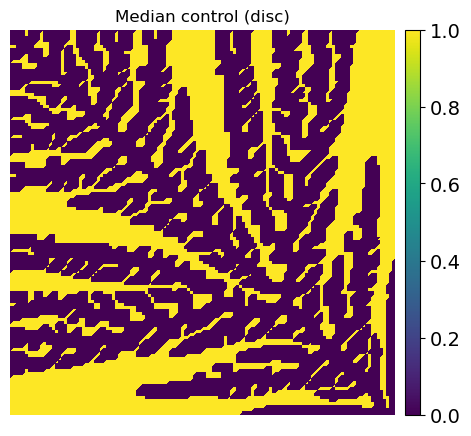

In [20]:
admm.plot_control(disc=True)

In [ ]:
# admm.trial(0).describe_tree()

### Here is an example on how to access the data in series group 

In [5]:
admm.trial(0).series.objective_disc
#admm.trial(0).series.infeas

array([4.37503283, 9.36165943, 1.40271502, 0.72128347, 0.80716405,
       0.72329837, 0.69978314, 0.71662901, 0.72199933, 0.69819547,
       0.69748798, 0.71365627, 0.71988884, 0.70317267, 0.70677891,
       0.70677891])

### Here is an example on how to access the data in iters group (5th control and state iterate)

In [4]:
control_5 = admm.trial(0).iters.control_2[10]
control_5_cont = admm.trial(0).iters.control_1[10]
state_5 = admm.trial(0).iters.state[15]

###  For randomized solver we store the median and best control, objective etc separately

In [5]:
admm.objective   #median
admm.objective_best #best

## Same for control
admm.control_1   #median
admm.control_1_best #best

array([1.        , 1.00000001, 1.        , ..., 1.00000001, 1.        ,
       1.00000001])

### Plot the best and median control across runs

Please enter a valid value for 'which' \in {1, 2}


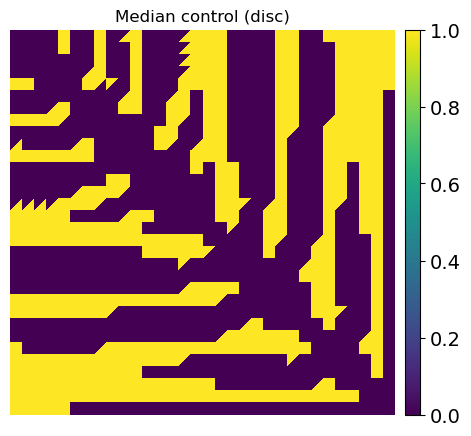

In [16]:
admm.plot_control(disc=True) #median

### To plot a specific iterate, you can pass it as an argument

Please enter a valid value for 'which' \in {1, 2}


/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/dolfin/common/plotting.py:152: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  return ax.tricontourf(mesh2triang(mesh), C, levels, **kwargs)


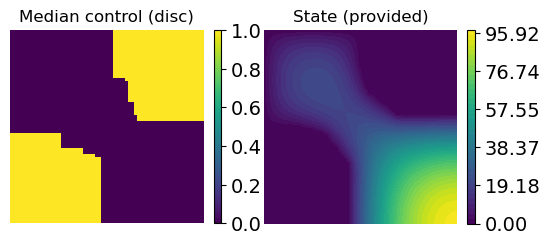

In [8]:
fig,ax = plt.subplots(figsize=(6,6), nrows=1, ncols=2)

c5 = admm.trial(0).iters.control_1[5]
s5 = admm.trial(0).iters.state[5]
admm.plot_control(disc=True, ax=ax[0])
admm.plot_state(s5, ax=ax[1])

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/dolfin/common/plotting.py:152: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  return ax.tricontourf(mesh2triang(mesh), C, levels, **kwargs)


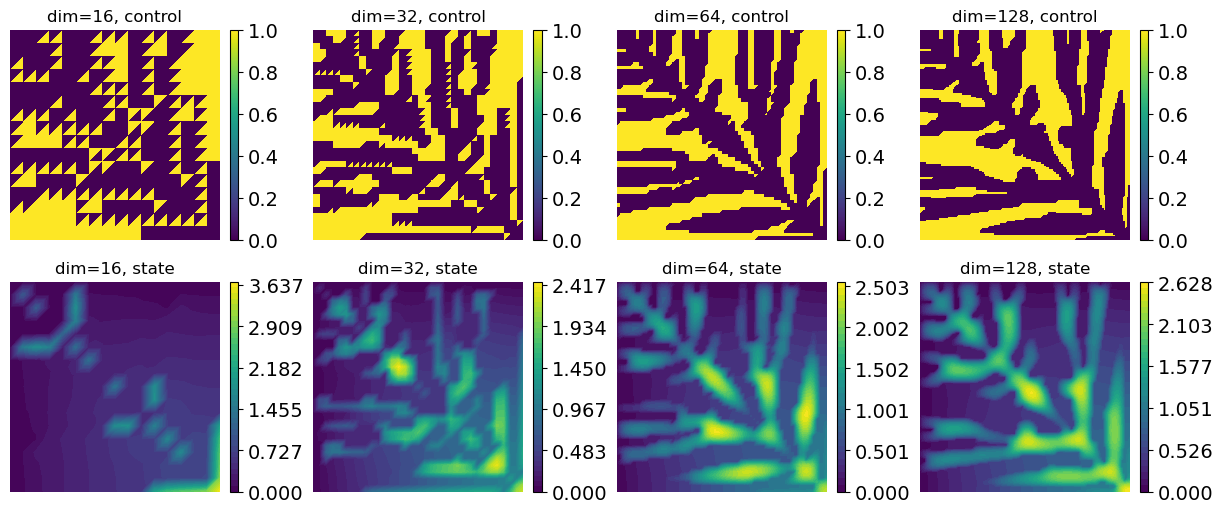

In [2]:
mesh_list = [16,32,64,128]
fig,ax = plt.subplots(figsize=(15,6), nrows=2, ncols=4)
for i, mesh in enumerate(mesh_list):
    admmcolin = ADMM(alpha=0.01, dim=mesh, base_dir="run_data_admm_gurobi_great")
    c = admmcolin.trial(0).iters.control_disc[-1]
    s = admmcolin.trial(0).iters.state[-1]
    admmcolin.plot_control(c, ax=ax[0][i], show=False, title=f"dim={mesh}, control")
    admmcolin.plot_state(s, ax=ax[1][i], show=False, title=f"dim={mesh}, state")

In [87]:
admm = ADMM(alpha=1.0, dim=64, base_dir="run_data_admm_gurobi")
admm.trial(0).series.objective

array([ 2.16424073, 18.80230254,  5.78794002,  3.21425851,  2.29886303,
        2.11107003,  2.0994079 ,  2.09016166,  2.07954719,  2.0657853 ,
        2.0478469 ,  2.02653678,  2.0001248 ,  1.98344569,  1.97704203,
        1.97351538,  1.96859783,  1.9656013 ,  1.96450629,  1.96361769,
        1.96295534])

In [90]:
admm.trial(0).series.runtime_sub1.sum()

76.72086810541805

In [91]:
admm.trial(0).series.runtime_sub2.sum()

533.6516651236452

In [3]:
admm.trial(0).meta

{'alpha': 0.1,
 'backend': 'gurobi',
 'dim': 64,
 'final_iter': 20,
 'idx': 2,
 'rho_final': 35.0,
 'rho_init': '20,35,115'}

In [3]:
admm = ADMM(alpha=0.01, dim=64, base_dir="run_data_admm_periodic_gurobi")
admm.trial(0).series.rho

array([20.      , 20.      , 20.      , 20.      , 20.      , 20.      ,
       20.      , 20.      , 20.      , 20.      , 20.      , 20.      ,
       24.      , 24.      , 28.8     , 28.8     , 34.56    , 34.56    ,
       41.472   , 41.472   , 49.7664  , 49.7664  , 59.71968 , 59.71968 ,
       71.663616, 71.663616])

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter


def _reshape_control_for_imshow(v, dim):
    v = np.asarray(v, dtype=float)
    target = dim * (2 * dim)
    if v.size == target:
        return v.reshape(dim, 2 * dim)
    n = int(np.sqrt(v.size))
    if n * n == v.size:
        return v.reshape(n, n)
    return v.reshape(1, -1)


def animate_admm_run(
    mesh_dim,
    base_dir,
    alpha=1.0,
    seed=0,
    output_gif=None,
    fps=8,
    interval_ms=180,
):
    """
    Create a 2x3 animation in the same style as admm_rho_interactive:
    Top row: b(control_1), a(control_2), a_rounded(control_disc)
    Bottom row: objective, infeasibility, rho

    Parameters
    ----------
    mesh_dim : int
        Mesh size.
    base_dir : str
        Folder like run_data_admm_running_avg_gurobi or run_data_admm_periodic_rho_gurobi.
    alpha : float
        Alpha value corresponding to the subfolder.
    seed : int
        Seed index.
    output_gif : str or None
        If None, auto-generates a filename.
    fps : int
        GIF frame rate.
    interval_ms : int
        Delay between frames in the live animation.
    """
    admm = ADMM(alpha=alpha, dim=mesh_dim, base_dir=base_dir)
    trial = admm.trial(seed)

    b_list = np.asarray(trial.iters.control_1)
    a_list = np.asarray(trial.iters.control_2)
    ar_list = np.asarray(trial.iters.control_disc)
    obj = np.asarray(trial.series.objective, dtype=float)
    inf = np.asarray(trial.series.infeas, dtype=float)

    try:
        rho = np.asarray(trial.series.rho, dtype=float)
    except Exception:
        rho = np.array([], dtype=float)

    n_frames = min(len(b_list), len(a_list), len(ar_list), len(obj), len(inf))
    if n_frames == 0:
        raise ValueError("No iterate history found to animate.")

    if len(rho) == 0:
        rho0 = float(trial.meta.get("rho_init", 0.0))
        rho = np.full(n_frames, rho0, dtype=float)
    elif len(rho) < n_frames:
        rho = np.concatenate([rho, np.full(n_frames - len(rho), rho[-1], dtype=float)])
    else:
        rho = rho[:n_frames]

    b_data = [_reshape_control_for_imshow(x, mesh_dim) for x in b_list[:n_frames]]
    a_data = [_reshape_control_for_imshow(x, mesh_dim) for x in a_list[:n_frames]]
    ar_data = [_reshape_control_for_imshow(x, mesh_dim) for x in ar_list[:n_frames]]
    iters = np.arange(n_frames)

    if output_gif is None:
        folder_tag = Path(base_dir).name.replace("/", "_")
        output_gif = f"admm_anim_{folder_tag}_alpha_{alpha}_dim_{mesh_dim}_seed_{seed}.gif"

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

    im_b = axs[0, 0].imshow(b_data[0], vmin=0.0, vmax=1.0, cmap="viridis", aspect="auto", origin="lower")
    im_a = axs[0, 1].imshow(a_data[0], vmin=0.0, vmax=1.0, cmap="viridis", aspect="auto", origin="lower")
    im_ar = axs[0, 2].imshow(ar_data[0], vmin=0.0, vmax=1.0, cmap="viridis", aspect="auto", origin="lower")

    axs[0, 0].set_title("b (control_1)")
    axs[0, 1].set_title("a (control_2)")
    axs[0, 2].set_title("a_rounded (control_disc)")

    for ax in axs[0, :]:
        ax.set_xlabel("y-index")
        ax.set_ylabel("x-index")

    fig.colorbar(im_b, ax=axs[0, 0], fraction=0.046, pad=0.04)
    fig.colorbar(im_a, ax=axs[0, 1], fraction=0.046, pad=0.04)
    fig.colorbar(im_ar, ax=axs[0, 2], fraction=0.046, pad=0.04)

    (ln_obj,) = axs[1, 0].plot([], [], lw=2, label="objective")
    (pt_obj,) = axs[1, 0].plot([], [], "o", ms=6)
    axs[1, 0].set_title("Objective")
    axs[1, 0].set_xlim(0, max(1, n_frames - 1))
    axs[1, 0].set_yscale("log")
    obj_min, obj_max = np.nanmin(obj[:n_frames]), np.nanmax(obj[:n_frames])
    if obj_max - obj_min < 1e-12:
        obj_max = obj_min + 1.0
    axs[1, 0].set_ylim(obj_min, obj_max)
    axs[1, 0].grid(True, alpha=0.3)

    (ln_inf,) = axs[1, 1].plot([], [], lw=2, label="infeasibility", color="tab:orange")
    (pt_inf,) = axs[1, 1].plot([], [], "o", ms=6, color="tab:orange")
    axs[1, 1].set_title("Infeasibility")
    axs[1, 1].set_xlim(0, max(1, n_frames - 1))
    axs[1, 1].set_yscale("log")
    inf_min, inf_max = np.nanmin(inf[:n_frames]), np.nanmax(inf[:n_frames])
    if inf_max - inf_min < 1e-12:
        inf_max = inf_min + 1.0
    axs[1, 1].set_ylim(inf_min, inf_max)
    axs[1, 1].grid(True, alpha=0.3)

    (ln_rho,) = axs[1, 2].plot([], [], lw=2, label="rho", color="tab:green")
    (pt_rho,) = axs[1, 2].plot([], [], "o", ms=6, color="tab:green")
    axs[1, 2].set_title("rho")
    axs[1, 2].set_xlim(0, max(1, n_frames - 1))
    rho_min, rho_max = np.nanmin(rho), np.nanmax(rho)
    if rho_max - rho_min < 1e-12:
        rho_max = rho_min + 1.0
    axs[1, 2].set_ylim(rho_min, rho_max)
    axs[1, 2].grid(True, alpha=0.3)

    for ax in axs[1, :]:
        ax.set_xlabel("iteration")

    def update(frame):
        im_b.set_data(b_data[frame])
        im_a.set_data(a_data[frame])
        im_ar.set_data(ar_data[frame])

        x = iters[: frame + 1]
        ln_obj.set_data(x, obj[: frame + 1])
        ln_inf.set_data(x, inf[: frame + 1])
        ln_rho.set_data(x, rho[: frame + 1])

        pt_obj.set_data([frame], [obj[frame]])
        pt_inf.set_data([frame], [inf[frame]])
        pt_rho.set_data([frame], [rho[frame]])

        fig.suptitle(
            f"ADMM iteration {frame} | base_dir={base_dir} | alpha={alpha} | dim={mesh_dim} | seed={seed}",
            fontsize=12,
        )
        return [im_b, im_a, im_ar, ln_obj, ln_inf, ln_rho, pt_obj, pt_inf, pt_rho]

    ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=interval_ms, blit=False)
    ani.save(output_gif, writer=PillowWriter(fps=fps))
    plt.close(fig)

    print(f"Saved GIF: {output_gif}")
    return output_gif


def run_admm_animation(mesh_dim, folder, alpha=1.0, seed=0, fps=8):
    """Wrapper requested for quick calls by mesh dim and folder."""
    return animate_admm_run(
        mesh_dim=mesh_dim,
        base_dir=folder,
        alpha=alpha,
        seed=seed,
        fps=fps,
    )

In [8]:
# Example calls (uncomment one):
run_admm_animation(mesh_dim=128, folder="run_data_admm_running_avg_gurobi", alpha=0.01, seed=0)
# run_admm_animation(mesh_dim=64, folder="run_data_admm_periodic_rho_gurobi", alpha=0.01, seed=0)


Saved GIF: admm_anim_run_data_admm_running_avg_gurobi_alpha_0.01_dim_128_seed_0.gif


'admm_anim_run_data_admm_running_avg_gurobi_alpha_0.01_dim_128_seed_0.gif'

In [9]:
run_admm_animation(mesh_dim=128, folder="run_data_admm_periodic_gurobi", alpha=0.01, seed=0)

Saved GIF: admm_anim_run_data_admm_periodic_gurobi_alpha_0.01_dim_128_seed_0.gif


'admm_anim_run_data_admm_periodic_gurobi_alpha_0.01_dim_128_seed_0.gif'

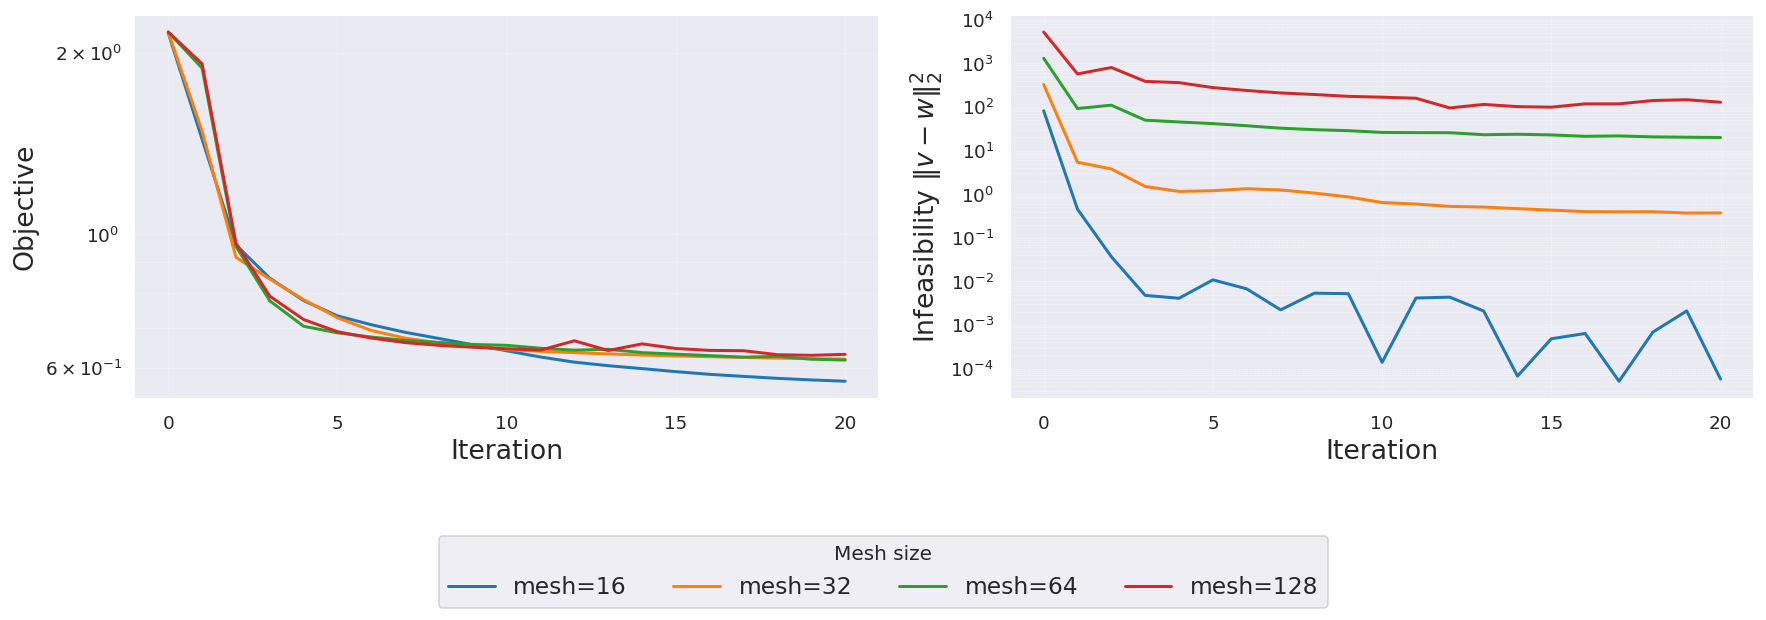

In [14]:
# Objective + infeasibility trajectories across mesh sizes (side-by-side)
mesh_sizes = [16, 32, 64, 128]
base_dir = "run_data_admm_gurobi_great"
#base_dir = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0

# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,
    "lines.linewidth": 2.8,
    "lines.markersize": 5,
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
colors = [cmap(i % cmap.N) for i in range(len(mesh_sizes))]


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for mesh, color in zip(mesh_sizes, colors):
    trial_series = ADMM(alpha=alpha, dim=mesh, base_dir=base_dir).trial(seed).series
    objective = np.asarray(trial_series.objective, dtype=float)
    infeas = np.asarray(trial_series.infeas, dtype=float)

    ax[0].plot(
        np.arange(len(objective)),
        objective,
        color=color,
        linewidth=1.8,
        label=f"mesh={mesh}",
        alpha=1.0,
    )

    ax[1].plot(
        np.arange(len(infeas)),
        infeas,
        color=color,
        linewidth=1.8,
        label=f"mesh={mesh}",
        alpha=1.0,
    )


# Objective plot
# ax[0].set_title("Objective Trajectories")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Objective")
ax[0].set_yscale("log")
ax[0].grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)
ax[0].set_xticks([0, 5, 10, 15, 20])

# Infeasibility plot
# ax[1].set_title("Infeasibility Trajectories")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel(r"Infeasibility $\|v-w\|_2^2$")
ax[1].set_yscale("log")
ax[1].grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)
ax[1].set_xticks([0, 5, 10, 15, 20])


# One shared legend below both plots
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mesh size",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.1),
    ncol=len(mesh_sizes),
    frameon=True,
)

plt.tight_layout(rect=(0, 0.15, 1, 1))
plt.show()

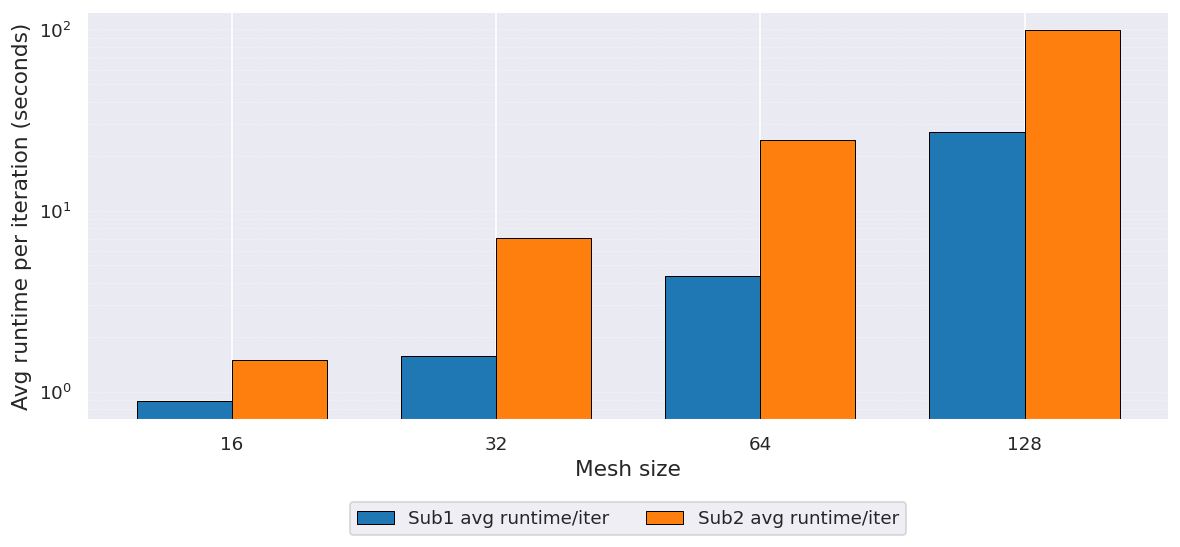

mesh= 16 | sub1=8.870e-01 s/iter | sub2=1.491e+00 s/iter
mesh= 32 | sub1=1.573e+00 s/iter | sub2=7.023e+00 s/iter
mesh= 64 | sub1=4.369e+00 s/iter | sub2=2.461e+01 s/iter
mesh=128 | sub1=2.703e+01 s/iter | sub2=9.869e+01 s/iter


In [3]:
# Runtime comparison across mesh sizes: average per-iteration subproblem runtime
mesh_sizes = [16, 32, 64, 128]
base_dir = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0

avg_sub1 = []
avg_sub2 = []

for mesh in mesh_sizes:
    trial_series = ADMM(alpha=alpha, dim=mesh, base_dir=base_dir).trial(seed).series
    runtime_sub1 = np.asarray(trial_series.runtime_sub1, dtype=float)
    runtime_sub2 = np.asarray(trial_series.runtime_sub2, dtype=float)

    avg_sub1.append(runtime_sub1.mean() if runtime_sub1.size > 0 else np.nan)
    avg_sub2.append(runtime_sub2.mean() if runtime_sub2.size > 0 else np.nan)


# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,
    "lines.linewidth": 2.8,
    "lines.markersize": 5,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(2)]


x = np.arange(len(mesh_sizes))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    avg_sub1,
    width=width,
    color=colors[0],
    edgecolor="black",
    linewidth=0.6,
    label="Sub1 avg runtime/iter",
)

ax.bar(
    x + width / 2,
    avg_sub2,
    width=width,
    color=colors[1],
    edgecolor="black",
    linewidth=0.6,
    label="Sub2 avg runtime/iter",
)

ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in mesh_sizes])
ax.set_xlabel("Mesh size")
ax.set_ylabel("Avg runtime per iteration (seconds)")
# ax.set_title("Per-Iteration Runtime by Mesh Size")

ax.set_yscale("log")

ax.grid(
    True,
    axis="y",
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Legend below plot, same style as your second example
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


for mesh, r1, r2 in zip(mesh_sizes, avg_sub1, avg_sub2):
    print(f"mesh={mesh:>3} | sub1={r1:.3e} s/iter | sub2={r2:.3e} s/iter")

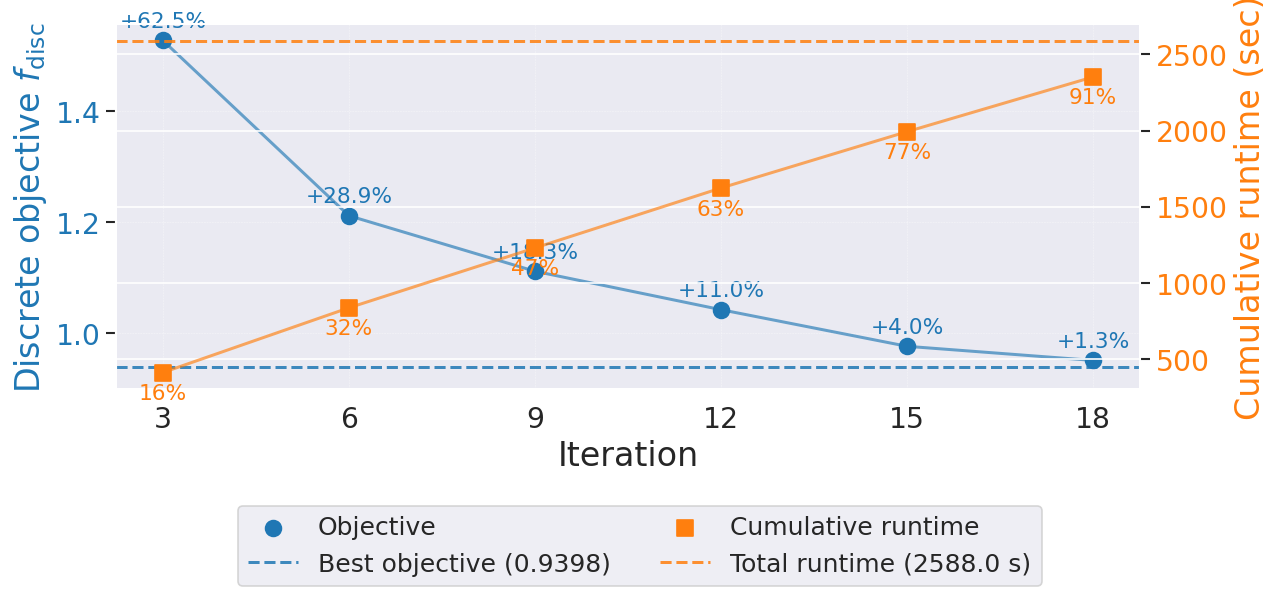

In [18]:
# Convergence vs. runtime tradeoff: objective_disc & cumulative runtime at every 3 iterations
dim = 128
objective_dir = "run_data_admm_gurobi_great"
runtime_dir   = "run_data_admm_running_avg_gurobi"
alpha = 0.01
seed = 0
step = 3

# --- nicer plotting style (seaborn optional) ---
import matplotlib as mpl

base_rc = {
    "figure.dpi": 120,

    # line style
    "lines.linewidth": 2.8,
    "lines.markersize": 6,

    # global font sizes
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,
    "legend.title_fontsize": 16,
}

try:
    import seaborn as sns
    sns.set_theme(style="darkgrid")
    mpl.rcParams.update(base_rc)
except Exception:
    mpl.rcParams.update(base_rc)


trial_obj = ADMM(alpha=alpha, dim=dim, base_dir=objective_dir).trial(seed)
trial_rt  = ADMM(alpha=alpha, dim=dim, base_dir=runtime_dir).trial(seed)

obj_disc = np.asarray(trial_obj.series.objective_disc, dtype=float)
rt_sub1  = np.asarray(trial_rt.series.runtime_sub1, dtype=float)
rt_sub2  = np.asarray(trial_rt.series.runtime_sub2, dtype=float)

# cumulative total runtime at each completed iteration
n_iters_rt = min(len(rt_sub1), len(rt_sub2))
cum_runtime = np.cumsum(rt_sub1[:n_iters_rt] + rt_sub2[:n_iters_rt])

# align obj_disc: if it carries an extra initial entry at index 0, drop it
n_iters_obj = len(obj_disc)
if n_iters_obj == n_iters_rt + 1:
    obj_disc = obj_disc[1:]

n_iters = min(len(obj_disc), n_iters_rt)
obj_disc = obj_disc[:n_iters]
cum_runtime = cum_runtime[:n_iters]

# reference values for the dashed lines
max_runtime = cum_runtime[-1]
best_obj_disc = np.nanmin(obj_disc)

# select every step-th iteration
tick_iters = np.arange(step - 1, n_iters, step)

# Use tab10 colorblind-friendly palette
cmap = plt.get_cmap("tab10")
color_obj = cmap(0)
color_rt = cmap(1)


fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

sc1 = ax1.scatter(
    tick_iters + 1,
    obj_disc[tick_iters],
    marker="o",
    s=90,
    color=color_obj,
    zorder=3,
    label="Objective",
)

ln1 = ax1.plot(
    tick_iters + 1,
    obj_disc[tick_iters],
    color=color_obj,
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)

sc2 = ax2.scatter(
    tick_iters + 1,
    cum_runtime[tick_iters],
    marker="s",
    s=90,
    color=color_rt,
    zorder=3,
    label="Cumulative runtime",
)

ln2 = ax2.plot(
    tick_iters + 1,
    cum_runtime[tick_iters],
    color=color_rt,
    linewidth=1.8,
    alpha=0.65,
    zorder=2,
)


# --- annotations ---
for idx in tick_iters:
    pct_obj = (obj_disc[idx] - best_obj_disc) / abs(best_obj_disc) * 100
    pct_rt = cum_runtime[idx] / max_runtime * 100

    ax1.annotate(
        f"+{pct_obj:.1f}%",
        xy=(idx + 1, obj_disc[idx]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=13,
        color=color_obj,
    )

    ax2.annotate(
        f"{pct_rt:.0f}%",
        xy=(idx + 1, cum_runtime[idx]),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        fontsize=13,
        color=color_rt,
    )


# --- reference dashed lines ---
hl_rt = ax2.axhline(
    max_runtime,
    color=color_rt,
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Total runtime ({max_runtime:.1f} s)",
)

hl_obj = ax1.axhline(
    best_obj_disc,
    color=color_obj,
    linewidth=1.8,
    linestyle="--",
    alpha=0.85,
    label=f"Best objective ({best_obj_disc:.4g})",
)


ax1.set_xlabel("Iteration")
ax1.set_ylabel(r"Discrete objective $f_{\rm disc}$", color=color_obj)
ax2.set_ylabel("Cumulative runtime (sec)", color=color_rt)

ax1.tick_params(axis="y", labelcolor=color_obj)
ax2.tick_params(axis="y", labelcolor=color_rt)

ax1.set_xticks(tick_iters + 1)
ax1.set_ylim(bottom=0.9)

ax1.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.3,
    alpha=0.6,
)

# Optional title; comment out if you want the clean paper-style look
# fig.suptitle(
#     f"Convergence vs. Runtime Tradeoff  |  dim={dim}, alpha={alpha}",
#     fontsize=20,
# )


handles = [sc1, hl_obj, sc2, hl_rt]
labels = [h.get_label() for h in handles]

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.15),
    ncol=2,
    frameon=True,
)

plt.tight_layout(rect=(0, 0.13, 1, 1))
plt.show()